In [28]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [29]:
#Cargar datos
df = pd.read_excel("../Base_de_datos.xlsx")
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [30]:
print('Información del dataset')
print(f'Número de clientes:  {df.shape[0]}')
print(f'Número de variables: {df.shape[1]}')

Información del dataset
Número de clientes:  10763
Número de variables: 23


In [31]:
#Info del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

Datos faltantes: puntaje_datacredito, saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor, promedio_ingresos_datacredito, tendencia_ingresos.
Los tipos de datos se observan bien definidos 

In [32]:
print("--- Tipos de datos  ---")
columnas_numericas = df.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print(f"Variables Numéricas ({len(columnas_numericas)}): {columnas_numericas}")
print(f"Variables Categóricas ({len(columnas_categoricas)}): {columnas_categoricas}")

--- Tipos de datos  ---
Variables Numéricas (20): ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']
Variables Categóricas (2): ['tipo_laboral', 'tendencia_ingresos']


In [33]:
#Revisión de duplicados
df.duplicated().sum()

np.int64(0)

No se evidencian registros duplicados, todos difieren en al menos 1 dato dentro del registro

In [34]:
#Verificación de errores tipográficos en columnas str
print(f"Datos para 'tipo_laboral': {df['tipo_laboral'].unique()}")
print("------------------")
print(f"Datos para 'tendencia_ingresos': {df['tendencia_ingresos'].unique()}")


Datos para 'tipo_laboral': <ArrowStringArray>
['Independiente', 'Empleado']
Length: 2, dtype: str
------------------
Datos para 'tendencia_ingresos': ['Estable' 'Creciente' nan 'Decreciente' 8315 0 158042 3978 9147 168750
 -28589 1000000 -566272 24702 31837 122727 417087 9090 173031 -70715
 -435177 -702927 -4105 54683 22832 209090 5697 10808 -288 -164315 2029000
 17181 15245 82657 52862 1817052 75761 146918 1123000 15090 4250635 22363
 -101368 86286 65988 77975 -224714]


Se requiere hacer limpieza de datos en la columna 'tendencia_ingresos', solo se dejarán las opciones de 'Estable' 'Creciente' 'Decreciente'

In [35]:
valid_values = ["Estable", "Creciente", "Decreciente"]

#Reemplazamos por NaN todo lo que NO esté en la lista de valores válidos
df.loc[~df["tendencia_ingresos"].isin(valid_values), "tendencia_ingresos"] = np.nan

# Verificar los resultados
print(df["tendencia_ingresos"].value_counts(dropna=False))

print(f"Tipo de dato de tendencia_ingresos: {df["tendencia_ingresos"].dtype}")

tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64
Tipo de dato de tendencia_ingresos: object


In [36]:
#Revisión de nulos
Null_Total = df.isnull().sum()
Null_percentage = ((df.isnull().sum())/len(df))*100
Null_Table = pd.DataFrame({"Total Nulos": Null_Total,
    "Porcentaje (%)":Null_percentage})
print(Null_Table.round(2))

                               Total Nulos  Porcentaje (%)
tipo_credito                             0            0.00
fecha_prestamo                           0            0.00
capital_prestado                         0            0.00
plazo_meses                              0            0.00
edad_cliente                             0            0.00
tipo_laboral                             0            0.00
salario_cliente                          0            0.00
total_otros_prestamos                    0            0.00
cuota_pactada                            0            0.00
puntaje                                  0            0.00
puntaje_datacredito                      6            0.06
cant_creditosvigentes                    0            0.00
huella_consulta                          0            0.00
saldo_mora                             156            1.45
saldo_total                            156            1.45
saldo_principal                        405            3.

Las variables promedio_ingresos_datacredito y tendencia_ingresos presentan un 27% de nulos de manera simultánea, lo que sugiere una falta de historial en la entidad financiera para un segmento específico de clientes. Para el caso, se descarta la eliminación de registros para evitar una pérdida crítica del 28% del dataset. Se procederá a imputar tendencia_ingresos bajo la etiqueta 'Sin Información' para conservar su información, y se evaluará la imputación por mediana para los ingresos numéricos.
Para las otras columnas se inputará con la mediana al ser menor al 10%

In [37]:
#Medidas de tendencias de las variables, variable de interé: Pago_atiempo
df.describe()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,...,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,...,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,...,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,...,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,...,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,...,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,...,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


Hallazgos:
Puntaje de datacrédito min de -7 es anómalo, se tendrá en el radar, sin embargo, se incluirá dentro del análisis debido a la falta de información de qué significa y cómo se calcula esta columna

Gráficas exploratorias

Análisis univariable

Número de clientes Al Día (1): 10252 (95.25%)
Número de clientes en Incumplimiento (0): 511 (4.75%)
Ratio de desbalanceo: 20.06:1


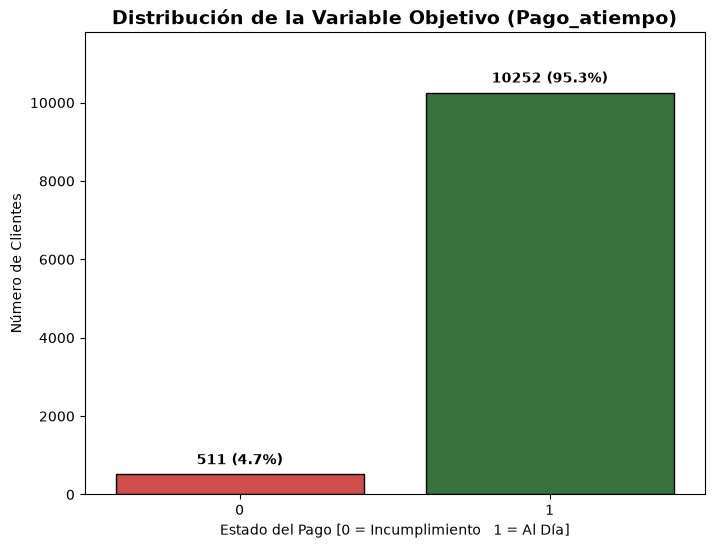

In [44]:
# Distribución de pago_atiempo
# Cálculos analíticos 
pago_count = df["Pago_atiempo"].value_counts()
pago_percentages = df["Pago_atiempo"].value_counts(normalize=True) * 100

print(f"Número de clientes Al Día (1): {pago_count[1]} ({pago_percentages[1]:.2f}%)")
print(f"Número de clientes en Incumplimiento (0): {pago_count[0]} ({pago_percentages[0]:.2f}%)")
print(f"Ratio de desbalanceo: {pago_count[1]/pago_count[0]:.2f}:1")

# 
plt.figure(figsize=(8, 6))
colors = ["#E53935", "#2E7D32"] # Rojo para mora, Verde para al día
ax = sns.countplot(x="Pago_atiempo", data=df, palette=colors, edgecolor="black", hue="Pago_atiempo", legend=False)

plt.title("Distribución de la Variable Objetivo (Pago_atiempo)", fontsize=14, fontweight="bold")
plt.xlabel("Estado del Pago [0 = Incumplimiento   1 = Al Día]")
plt.ylabel("Número de Clientes")

# Etiquetas individuales para cada barra
label_incumplimiento = [f"{pago_count[0]} ({pago_percentages[0]:.1f}%)"]
label_aldia = [f"{pago_count[1]} ({pago_percentages[1]:.1f}%)"]

# cada etiqueta a su contenedor correspondiente
ax.bar_label(ax.containers[0], labels=label_incumplimiento, padding=5, fontweight="bold")
ax.bar_label(ax.containers[1], labels=label_aldia, padding=5, fontweight="bold")

# Ajustar el límite del eje Y un poco más arriba del máximo para que quepan las etiquetas
plt.ylim(0, df["Pago_atiempo"].value_counts().max() * 1.15)
plt.show()

Análisis multivariable: Heatmap

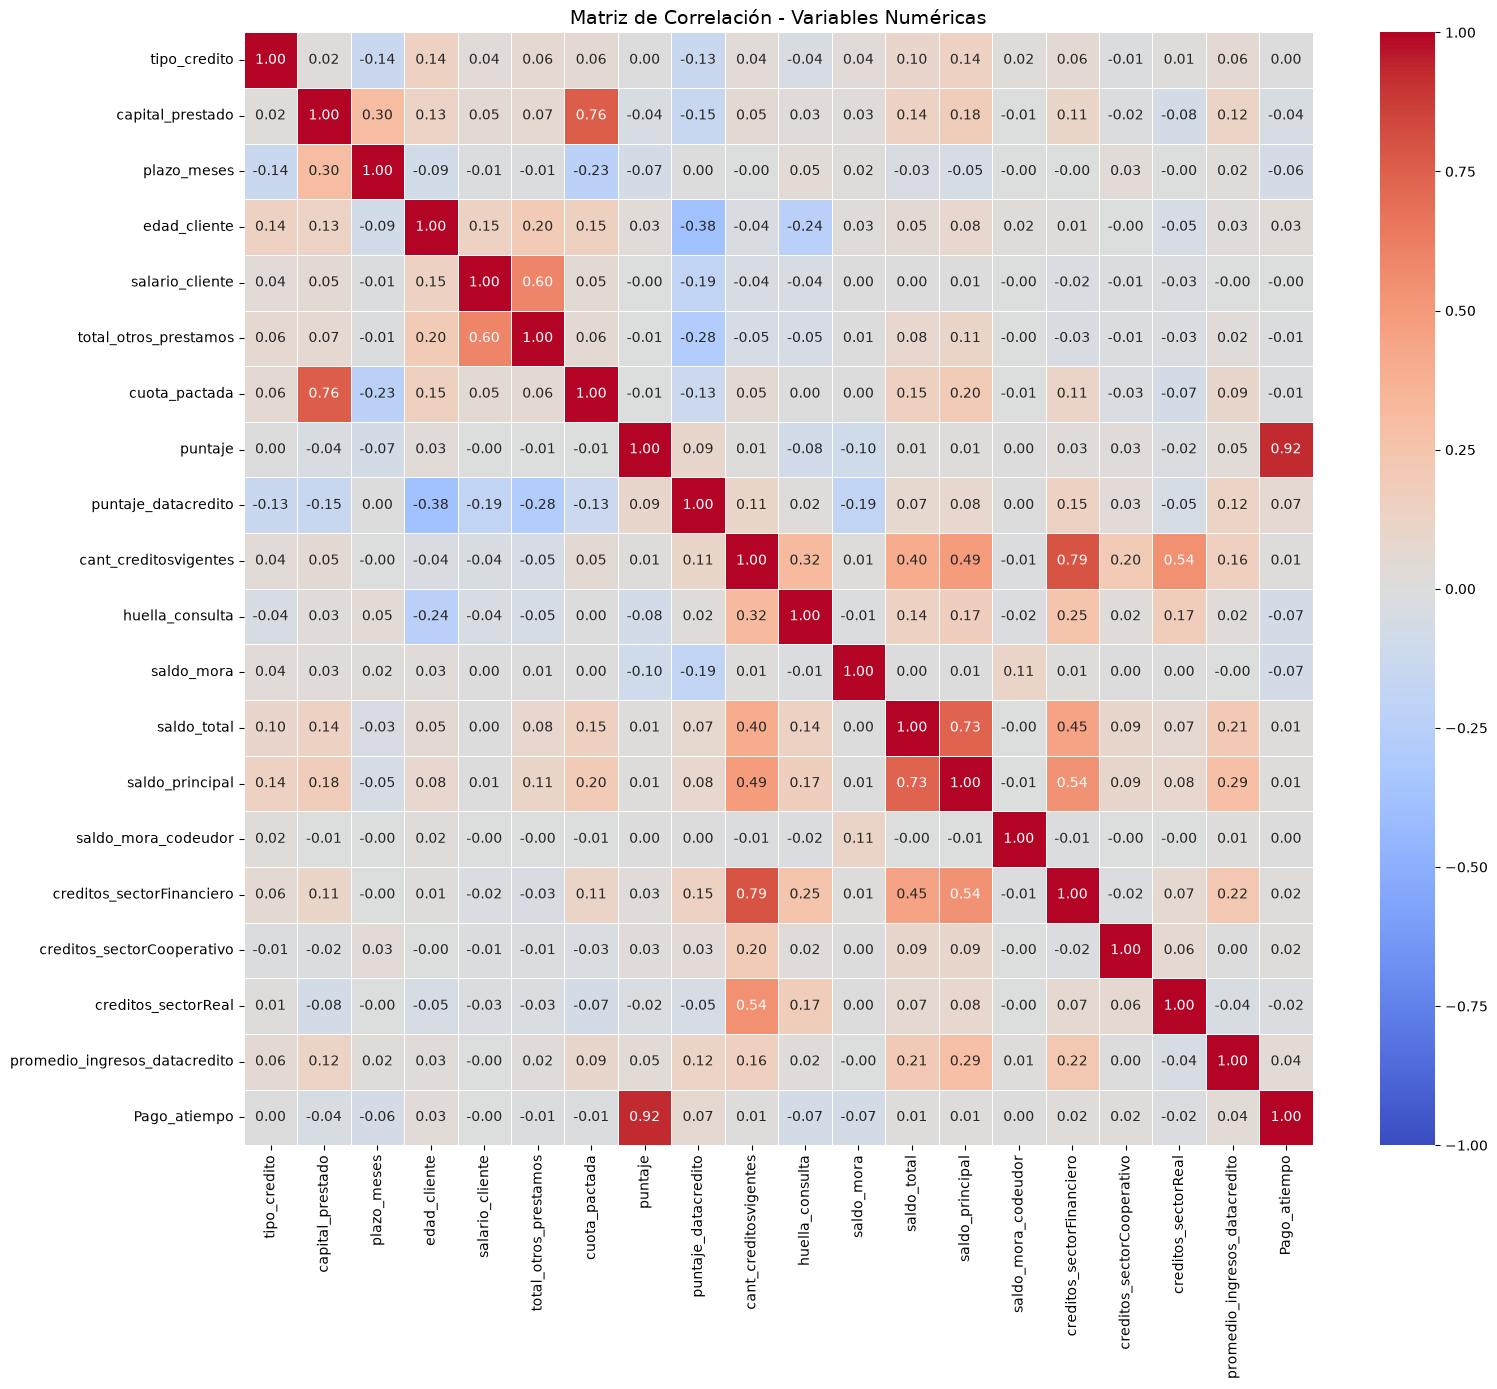

In [39]:
df_numerico = df.select_dtypes(include=["number"])

matriz_corr = df_numerico.corr()

plt.figure(figsize=(16, 14))

sns.heatmap(
    matriz_corr,
    annot=True,  # Coloca el valor numérico en cada celda
    cmap="coolwarm",  # Azul = Correlación negativa, Rojo = Correlación positiva
    fmt=".2f",  
    linewidths=0.5,  # Separa los cuadros con una línea delgada
    vmin=-1,
    vmax=1,  # Fija los límites de la escala de color
)

plt.title("Matriz de Correlación - Variables Numéricas", fontsize=14)
plt.tight_layout()
plt.show()

|0.70 a 1.00| : Alta a Muy Alta Correlación
|0.40 a 0.69| : Correlación Moderada
|0.00 a 0.39| : Correlación Baja a Nula

Con respecto a pago a tiempo la única variable altamente correlacionada es "puntaje"
Se obserba multicolinealidad entre: 
cant_creditosvigentes y creditos_sectorFinanciero (0.79)
saldo_total y saldo_principal (0.73)
capital_prestado y cuota_pactada (0.76)

Análisis bivariable

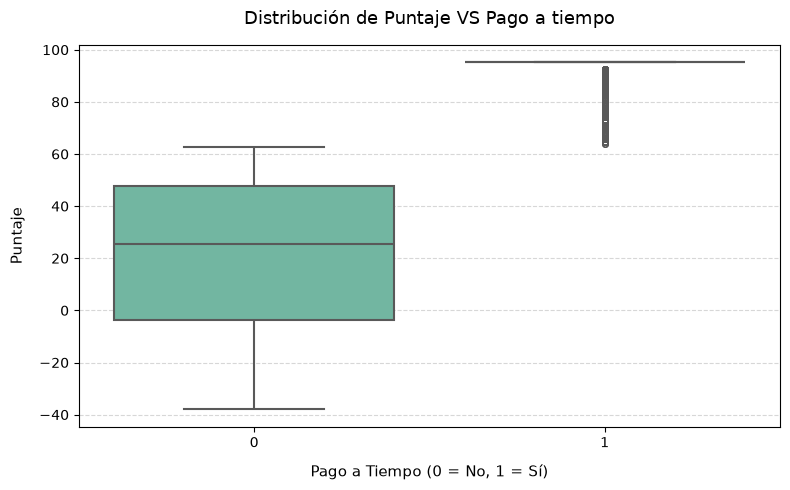

In [40]:

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="puntaje",
    palette="Set2",
    linewidth=1.5,
    fliersize=4,  # Tamaño de los puntos atípicos (outliers)
)

plt.title(
    "Distribución de Puntaje VS Pago a tiempo",
    fontsize=13,
    pad=15,
)
plt.xlabel("Pago a Tiempo (0 = No, 1 = Sí)", fontsize=11, labelpad=10)
plt.ylabel("Puntaje", fontsize=11, labelpad=10)

#Estética de la cuadrícula de fondo para medir mejor los cuartiles
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Tendencia fuerte marcada. Por encima de los 60 puntos todos los clientes pagan y los que no, se encuentran por debajo de los 60 con una media de 25 puntos. No se tiene información de si es una medida calculada después del pago, si no, no sirve para predecir

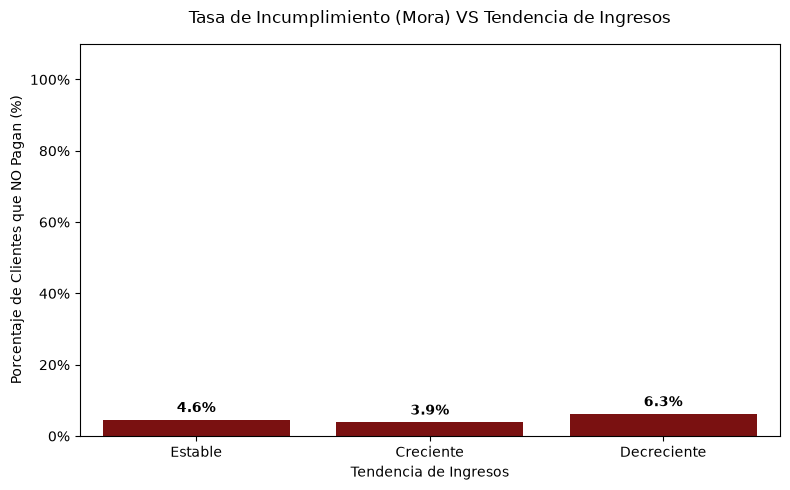

In [41]:
df["En_Mora"] = 1 - df["Pago_atiempo"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df, x="tendencia_ingresos", y="En_Mora", color="darkred", errorbar=None
)

#Formatear el eje Y a porcentaje entero
ax.set_ylim(0, 1.1)
ax.set_yticklabels([f"{int(x*100)}%" for x in ax.get_yticks()])

plt.title(
    "Tasa de Incumplimiento (Mora) VS Tendencia de Ingresos",
    fontsize=12,
    pad=15,
)
plt.xlabel("Tendencia de Ingresos", fontsize=10)
plt.ylabel("Porcentaje de Clientes que NO Pagan (%)", fontsize=10)

#Porcentaje sobre las barras
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        f"{altura * 100:.1f}%",
        (p.get_x() + p.get_width() / 2.0, altura),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
    )

plt.tight_layout()
plt.show()

Hay una tendencia ligera donde se evidencia que el número de clientes con incumplimiento en el pago aumenta cuando su tendencia de ingresos es decreciente, y son menores cuando su tendencia de ingresos es creciente.

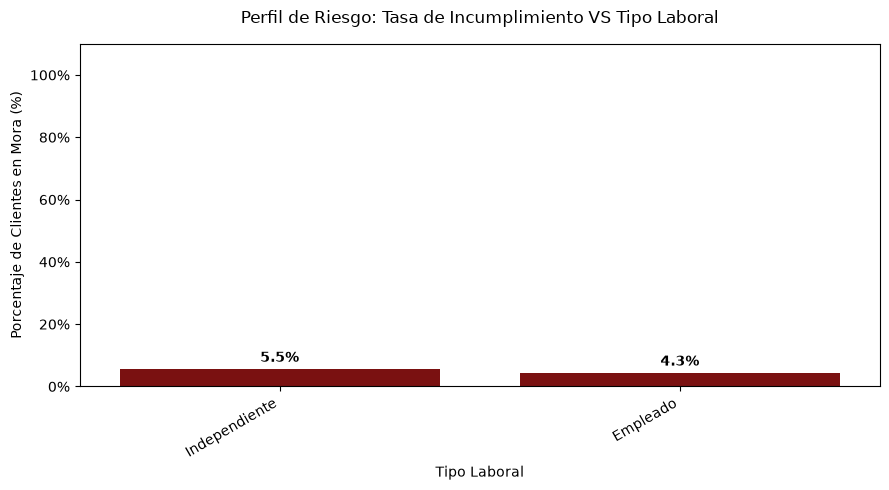

In [43]:
df["En_Mora"] = 1 - df["Pago_atiempo"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(data=df, x="tipo_laboral", y="En_Mora", color="darkred", errorbar=None)

# Formatear el eje Y porcentajes reales de 0% a 100%
ax.set_ylim(0, 1.1)
ax.set_yticklabels([f"{int(x*100)}%" for x in ax.get_yticks()])

plt.title(
    "Perfil de Riesgo: Tasa de Incumplimiento VS Tipo Laboral",
    fontsize=12,
    pad=15,
)
plt.xlabel("Tipo Laboral", fontsize=10)
plt.ylabel("Porcentaje de Clientes en Mora (%)", fontsize=10)
plt.xticks(rotation=30, ha="right")

# Porcentaje exacto arriba de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f"{altura * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=10,
            weight="bold",
        )

plt.tight_layout()
plt.show()

Las tasas en mora son similares en ambos perfiles, ligeramente mayor para los que son empleados independientes